In [3]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

ARTIFACTS_DIR = 'artifacts'
FIGURES_DIR = os.path.join(ARTIFACTS_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

DATA_PATH = 'data/S12-hw-dataset.csv'

Using device: cpu


Shape: (4320, 2)
Date range: 2025-01-01 00:00:00 to 2025-06-29 23:00:00
Missing values:
date      0
target    0
dtype: int64
                 date  target
0 2025-01-01 00:00:00   98.14
1 2025-01-01 01:00:00   98.07
2 2025-01-01 02:00:00  104.70
3 2025-01-01 03:00:00  112.81
4 2025-01-01 04:00:00  112.62


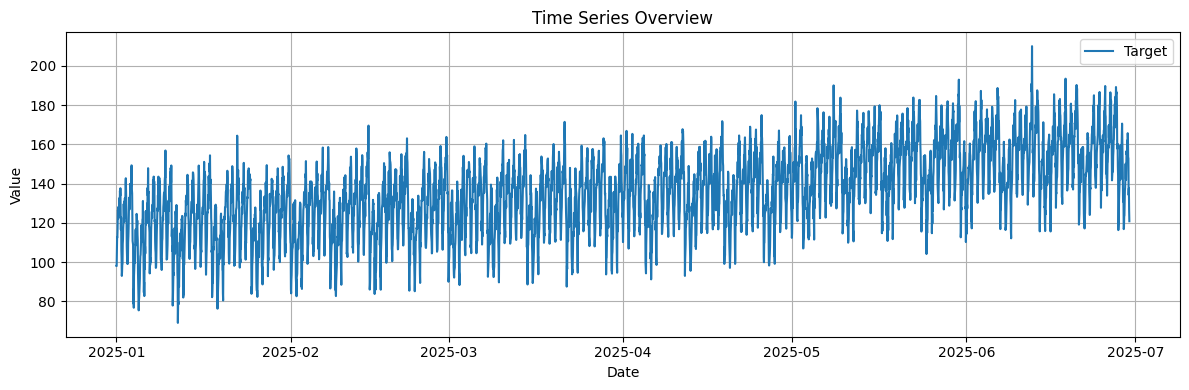

In [4]:
df = pd.read_csv(DATA_PATH)

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Sanity Check
print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"Missing values:\n{df.isnull().sum()}")
print(df.head())

plt.figure(figsize=(12, 4))
plt.plot(df['date'], df['target'], label='Target')
plt.title('Time Series Overview')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Train: 2592, Val: 864, Test: 864
Train dates: 2025-01-01 00:00:00 - 2025-04-18 23:00:00
Val dates:   2025-04-19 00:00:00 - 2025-05-24 23:00:00
Test dates:  2025-05-25 00:00:00 - 2025-06-29 23:00:00


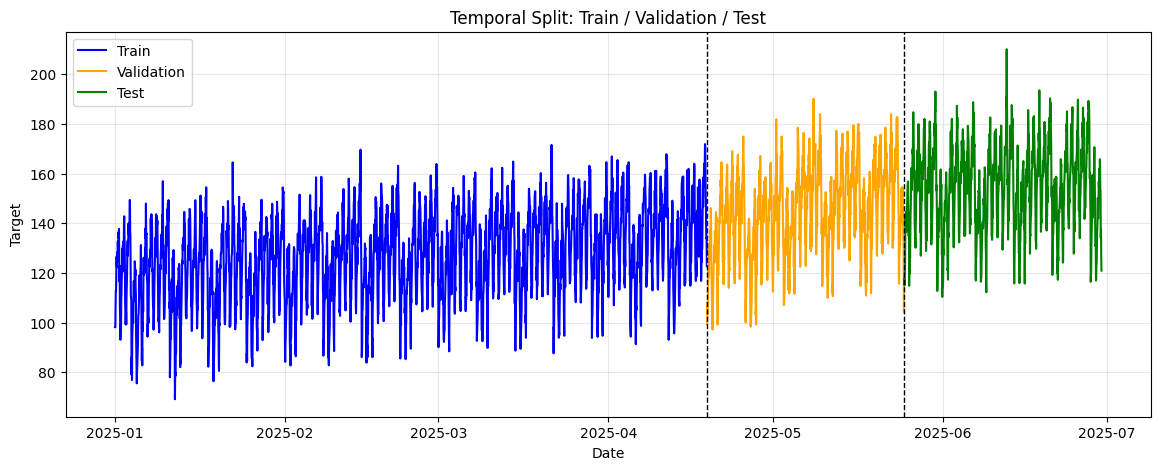

In [5]:
# Границы разбиения (60% train, 20% val, 20% test)
n = len(df)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Train dates: {train_df['date'].min()} - {train_df['date'].max()}")
print(f"Val dates:   {val_df['date'].min()} - {val_df['date'].max()}")
print(f"Test dates:  {test_df['date'].min()} - {test_df['date'].max()}")

# Визуализация split
plt.figure(figsize=(14, 5))
plt.plot(train_df['date'], train_df['target'], label='Train', color='blue')
plt.plot(val_df['date'], val_df['target'], label='Validation', color='orange')
plt.plot(test_df['date'], test_df['target'], label='Test', color='green')
plt.axvline(train_df['date'].max(), color='black', linestyle='--', linewidth=1)
plt.axvline(val_df['date'].max(), color='black', linestyle='--', linewidth=1)
plt.title('Temporal Split: Train / Validation / Test')
plt.xlabel('Date')
plt.ylabel('Target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(FIGURES_DIR, 'series_split.png'))
plt.show()

In [ ]:
def create_features(data, target_col='target'):
    df_feat = data.copy()
    
    # lag_7 and lag_14
    for lag in [1, 7, 14]:
        df_feat[f'lag_{lag}'] = df_feat[target_col].shift(lag)
        
    # Shift7
    df_feat['rolling_mean_7'] = df_feat[target_col].shift(1).rolling(window=7).mean()
    df_feat['rolling_std_7'] = df_feat[target_col].shift(1).rolling(window=7).std()
    
    # Календарные
    df_feat['day_of_week'] = df_feat['date'].dt.dayofweek
    df_feat['month'] = df_feat['date'].dt.month
    df_feat['day'] = df_feat['date'].dt.day
    
    return df_feat

df_full = create_features(df)

df_full = df_full.dropna().reset_index(drop=True)

n_new = len(df_full)
train_end = int(n_new * 0.6)
val_end = int(n_new * 0.8)

train_feat = df_full.iloc[:train_end]
val_feat = df_full.iloc[train_end:val_end]
test_feat = df_full.iloc[val_end:]

feature_cols = [c for c in df_full.columns if c not in ['date', 'target']]
print(f"Features: {feature_cols}")

Features: ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'month', 'day']


In [7]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    if np.sum(mask) > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = 0.0
    return {'mae': mae, 'rmse': rmse, 'mape': mape}

runs_log = []

def log_run(exp_id, model_name, metrics_val, metrics_test, notes="", **kwargs):
    row = {
        'experiment_id': exp_id,
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': SEED,
        'split_summary': f"Train:{train_end}, Val:{val_end-train_end}, Test:{n_new-val_end}",
        'window_size': kwargs.get('window_size', 'N/A'),
        'horizon': 1,
        'model_summary': model_name,
        'features_summary': ','.join(feature_cols) if 'Ridge' in model_name else 'Lags+Rolling+Calendar',
        'scaler': kwargs.get('scaler', 'None'),
        'optimizer': kwargs.get('optimizer', 'N/A'),
        'lr': kwargs.get('lr', 'N/A'),
        'epochs_trained': kwargs.get('epochs', 0),
        'best_val_mae': metrics_val['mae'],
        'best_val_rmse': metrics_val['rmse'],
        'best_val_mape': metrics_val['mape'],
        'test_mae': metrics_test['mae'],
        'test_rmse': metrics_test['rmse'],
        'test_mape': metrics_test['mape'],
        'notes': notes
    }
    runs_log.append(row)
    print(f"[{exp_id}] Val MAE: {metrics_val['mae']:.4f}, Test MAE: {metrics_test['mae']:.4f}")

In [8]:
# B1
def naive_last_predict(data, target_col='target'):
    return data[target_col].shift(1)

pred_val_b1 = naive_last_predict(val_feat)
pred_test_b1 = naive_last_predict(test_feat)
mask_val = ~pred_val_b1.isna()
mask_test = ~pred_test_b1.isna()

metrics_val_b1 = calculate_metrics(val_feat.loc[mask_val, 'target'], pred_val_b1.loc[mask_val])
metrics_test_b1 = calculate_metrics(test_feat.loc[mask_test, 'target'], pred_test_b1.loc[mask_test])
log_run('B1', 'Naive Last', metrics_val_b1, metrics_test_b1, notes="Last known value")

# B2
def moving_avg_predict(data, window=7, target_col='target'):
    return data[target_col].shift(1).rolling(window=window).mean()

pred_val_b2 = moving_avg_predict(val_feat)
pred_test_b2 = moving_avg_predict(test_feat)

mask_val = ~pred_val_b2.isna()
mask_test = ~pred_test_b2.isna()

metrics_val_b2 = calculate_metrics(val_feat.loc[mask_val, 'target'], pred_val_b2.loc[mask_val])
metrics_test_b2 = calculate_metrics(test_feat.loc[mask_test, 'target'], pred_test_b2.loc[mask_test])
log_run('B2', 'Moving Average (7)', metrics_val_b2, metrics_test_b2, notes="Rolling mean window 7")

#  B3
X_train = train_feat[feature_cols].values
y_train = train_feat['target'].values

X_val = val_feat[feature_cols].values
y_val = val_feat['target'].values

X_test = test_feat[feature_cols].values
y_test = test_feat['target'].values

# Масштабирование признаков для Ridge
scaler_ridge = StandardScaler()
X_train_s = scaler_ridge.fit_transform(X_train)
X_val_s = scaler_ridge.transform(X_val)
X_test_s = scaler_ridge.transform(X_test)

model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train_s, y_train)

pred_val_b3 = model_ridge.predict(X_val_s)
pred_test_b3 = model_ridge.predict(X_test_s)

metrics_val_b3 = calculate_metrics(y_val, pred_val_b3)
metrics_test_b3 = calculate_metrics(y_test, pred_test_b3)
log_run('B3', 'Ridge Regression', metrics_val_b3, metrics_test_b3, 
        notes="Scaled lag/rolling features", scaler="StandardScaler")

[B1] Val MAE: 6.4148, Test MAE: 6.3725
[B2] Val MAE: 12.7036, Test MAE: 12.7919
[B3] Val MAE: 6.0961, Test MAE: 6.0673


In [ ]:
# GRU
WINDOW_SIZE = 14
HIDDEN_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 50
LR = 0.001

scaler_target = StandardScaler()
train_target_scaled = scaler_target.fit_transform(train_feat[['target']]).flatten()
val_target_scaled = scaler_target.transform(val_feat[['target']]).flatten()
test_target_scaled = scaler_target.transform(test_feat[['target']]).flatten()

def create_sequences(data_scaled, features_scaled, window_size):
    X, y = [], []
    for i in range(len(data_scaled) - window_size):
        X.append(features_scaled[i:i+window_size])
        y.append(data_scaled[i+window_size])
    return np.array(X), np.array(y)

X_train_gru, y_train_gru = create_sequences(train_target_scaled, train_target_scaled, WINDOW_SIZE)
X_val_gru, y_val_gru = create_sequences(val_target_scaled, val_target_scaled, WINDOW_SIZE)
X_test_gru, y_test_gru = create_sequences(test_target_scaled, test_target_scaled, WINDOW_SIZE)

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TimeSeriesDataset(X_train_gru, y_train_gru), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TimeSeriesDataset(X_val_gru, y_val_gru), batch_size=BATCH_SIZE)
test_loader = DataLoader(TimeSeriesDataset(X_test_gru, y_test_gru), batch_size=BATCH_SIZE)

class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

model_gru = GRUModel(input_size=1, hidden_size=HIDDEN_SIZE).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_gru.parameters(), lr=LR)

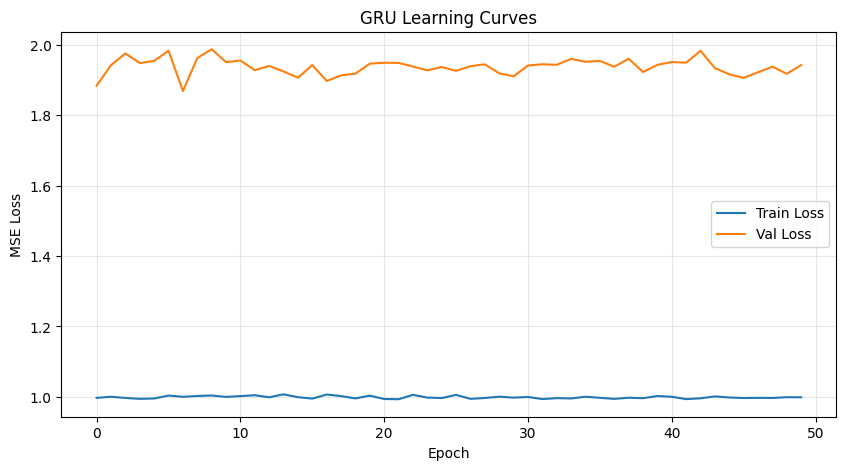

[R1] Val MAE: 20.9853, Test MAE: 28.0865


In [ ]:
import einops


best_val_loss = float('inf')
best_model_state = None
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model_gru.train()
    epoch_train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = einops.rearrange(X_batch.to(device), "a b -> a b 1"), y_batch.to(device)
        optimizer.zero_grad()
        output = model_gru(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()
    
    model_gru.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model_gru(einops.rearrange(X_batch, "a b -> a b 1"))
            loss = criterion(output, y_batch)
            epoch_val_loss += loss.item()
            
    avg_train_loss = epoch_train_loss / len(train_loader)
    avg_val_loss = epoch_val_loss / len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model_gru.state_dict()
        torch.save(best_model_state, os.path.join(ARTIFACTS_DIR, 'best_gru.pt'))

config = {
    'window_size': WINDOW_SIZE,
    'hidden_size': HIDDEN_SIZE,
    'batch_size': BATCH_SIZE,
    'lr': LR,
    'epochs': EPOCHS,
    'seed': SEED,
    'scaler': 'StandardScaler (Target)'
}
with open(os.path.join(ARTIFACTS_DIR, 'best_gru_config.json'), 'w') as f:
    json.dump(config, f, indent=4)

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('GRU Learning Curves')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(FIGURES_DIR, 'gru_learning_curves.png'))
plt.show()

model_gru.load_state_dict(best_model_state)
model_gru.eval()
preds_test_scaled = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        output = model_gru(einops.rearrange(X_batch, "a b -> a b 1")).cpu().numpy()
        preds_test_scaled.extend(output)

preds_test_gru = scaler_target.inverse_transform(np.array(preds_test_scaled).reshape(-1, 1)).flatten()
len_test = len(y_test_gru)
preds_test_gru = preds_test_gru[:len_test]

metrics_test_gru = calculate_metrics(scaler_target.inverse_transform(y_test_gru.reshape(-1, 1)).flatten(), preds_test_gru)
preds_val_scaled = []
model_gru.eval()
with torch.no_grad():
    for X_batch, _ in val_loader:
        X_batch = X_batch.to(device)
        output = model_gru(einops.rearrange(X_batch, "a b -> a b 1")).squeeze().cpu().numpy()
        preds_val_scaled.extend(output)
preds_val_gru = scaler_target.inverse_transform(np.array(preds_val_scaled).reshape(-1, 1)).flatten()
metrics_val_gru = calculate_metrics(scaler_target.inverse_transform(y_val_gru.reshape(-1, 1)).flatten(), preds_val_gru)

log_run('R1', 'GRU', metrics_val_gru, metrics_test_gru, 
        window_size=WINDOW_SIZE, optimizer='Adam', lr=LR, epochs=EPOCHS, scaler='StandardScaler')

Saved runs.csv


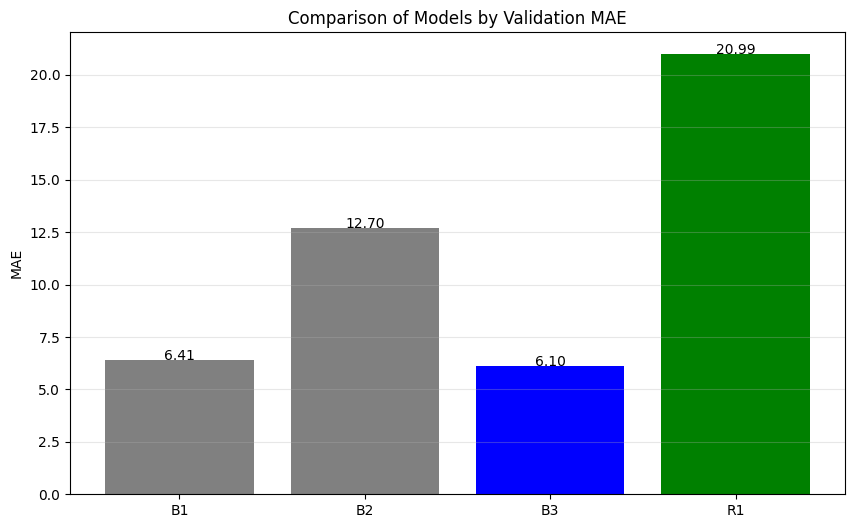

Best Model on Validation: B3


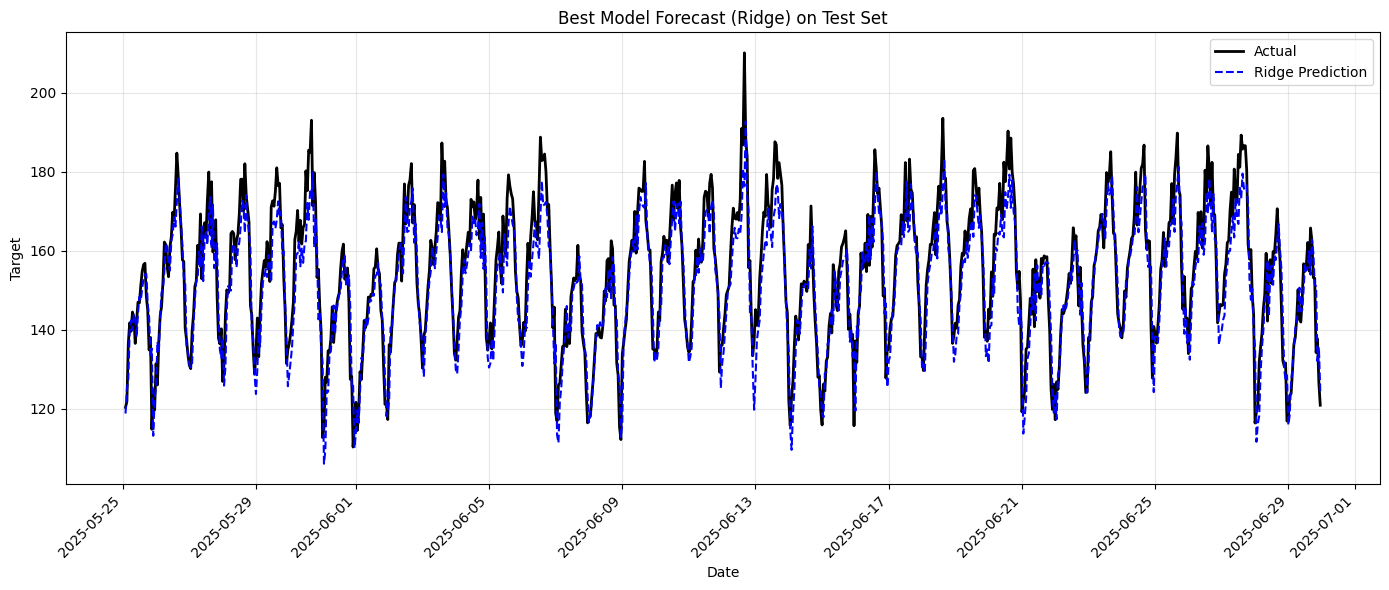

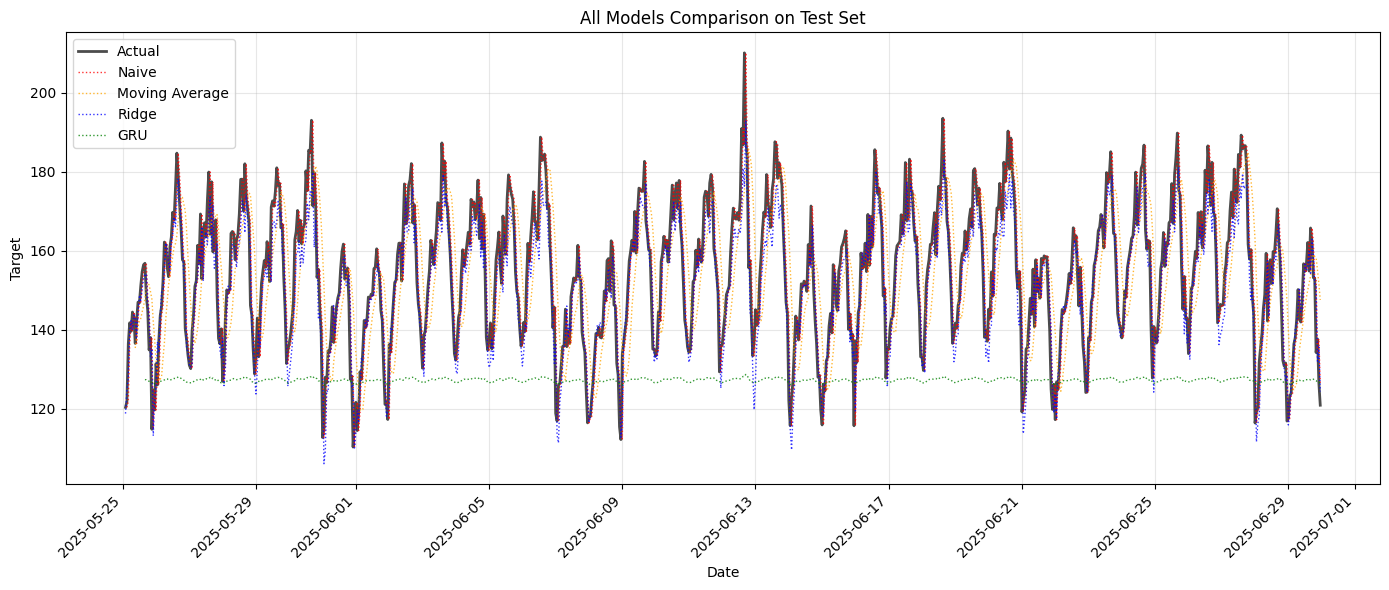

In [43]:
runs_df = pd.DataFrame(runs_log)
runs_df.to_csv(os.path.join(ARTIFACTS_DIR, 'runs.csv'), index=False)
print("Saved runs.csv")

plt.figure(figsize=(10, 6))
experiments = ['B1', 'B2', 'B3', 'R1']
val_maes = [r['best_val_mae'] for r in runs_log]
colors = ['gray', 'gray', 'blue', 'green']
plt.bar(experiments, val_maes, color=colors)
plt.title('Comparison of Models by Validation MAE')
plt.ylabel('MAE')
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(val_maes):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
plt.savefig(os.path.join(FIGURES_DIR, 'baselines_compare.png'))
plt.show()

test_indices = test_feat.index.values
test_dates_aligned = test_feat['date'].values
test_actual = test_feat['target'].values

predictions_dict = {
    'B1': pred_test_b1.values if hasattr(pred_test_b1, 'values') else pred_test_b1,
    'B2': pred_test_b2.values if hasattr(pred_test_b2, 'values') else pred_test_b2,
    'B3': pred_test_b3,
    'R1': preds_test_gru
}

for key in predictions_dict:
    pred = predictions_dict[key]
    if len(pred) > len(test_actual):
        predictions_dict[key] = pred[-len(test_actual):]
    elif len(pred) < len(test_actual):
        import numpy as np
        padding = np.full(len(test_actual) - len(pred), np.nan)
        predictions_dict[key] = np.concatenate([padding, pred])

best_run = runs_df.loc[runs_df['best_val_mae'].idxmin()]
best_exp_id = best_run['experiment_id']
print(f"Best Model on Validation: {best_exp_id}")

plt.figure(figsize=(14, 6))

plt.plot(test_dates_aligned, test_actual, label='Actual', linewidth=2, color='black')

pred_best = predictions_dict[best_exp_id]
label_map = {'B1': 'Naive', 'B2': 'Moving Average', 'B3': 'Ridge', 'R1': 'GRU'}
color_map = {'B1': 'red', 'B2': 'orange', 'B3': 'blue', 'R1': 'green'}

plt.plot(test_dates_aligned, pred_best, 
         label=f'{label_map[best_exp_id]} Prediction', 
         linestyle='--', color=color_map[best_exp_id], linewidth=1.5)

plt.title(f'Best Model Forecast ({label_map[best_exp_id]}) on Test Set')
plt.xlabel('Date')
plt.ylabel('Target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'best_forecast_test.png'), dpi=300)
plt.show()

plt.figure(figsize=(14, 6))
plt.plot(test_dates_aligned, test_actual, label='Actual', linewidth=2, color='black', alpha=0.7)

for exp_id in ['B1', 'B2', 'B3', 'R1']:
    plt.plot(test_dates_aligned, predictions_dict[exp_id], 
             label=label_map[exp_id], linestyle=':', 
             color=color_map[exp_id], alpha=0.8, linewidth=1)

plt.title('All Models Comparison on Test Set')
plt.xlabel('Date')
plt.ylabel('Target')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'all_models_test.png'), dpi=300)
plt.show()